# SHBT 261 AI in Medicine Mini Project 1

**Harvard University**\
**Spring 2026**\
**Instructors**: Mengyu Wang and Tobias Elze

<hr style="height:2pt">

In [20]:
# ── Imports ────────────────────────────────────────────────────────────────
# Standard Library
import os
import time
import copy

# Data & Math
import numpy as np
import pandas as pd
from pathlib import Path

# Image Processing
from PIL import Image
from skimage.feature import hog
from skimage.color import rgb2gray

# Progress Bar
from tqdm import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Classical ML
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, top_k_accuracy_score)

# Deep Learning — PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# Deep Learning — timm (ViT)
import timm

# Serialization
import joblib

print("All imports OK ✓")
print(f"PyTorch version : {torch.__version__}")
print(f"timm version    : {timm.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"MPS available   : {torch.backends.mps.is_available()}")

All imports OK ✓
PyTorch version : 2.4.1
timm version    : 1.0.25
CUDA available  : False
MPS available   : True


Found 101 classes
First 10: ['Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass']

Total images: 8677
Sample entry: (PosixPath('caltech-101/Faces/image_0146.jpg'), 0, 'Faces')


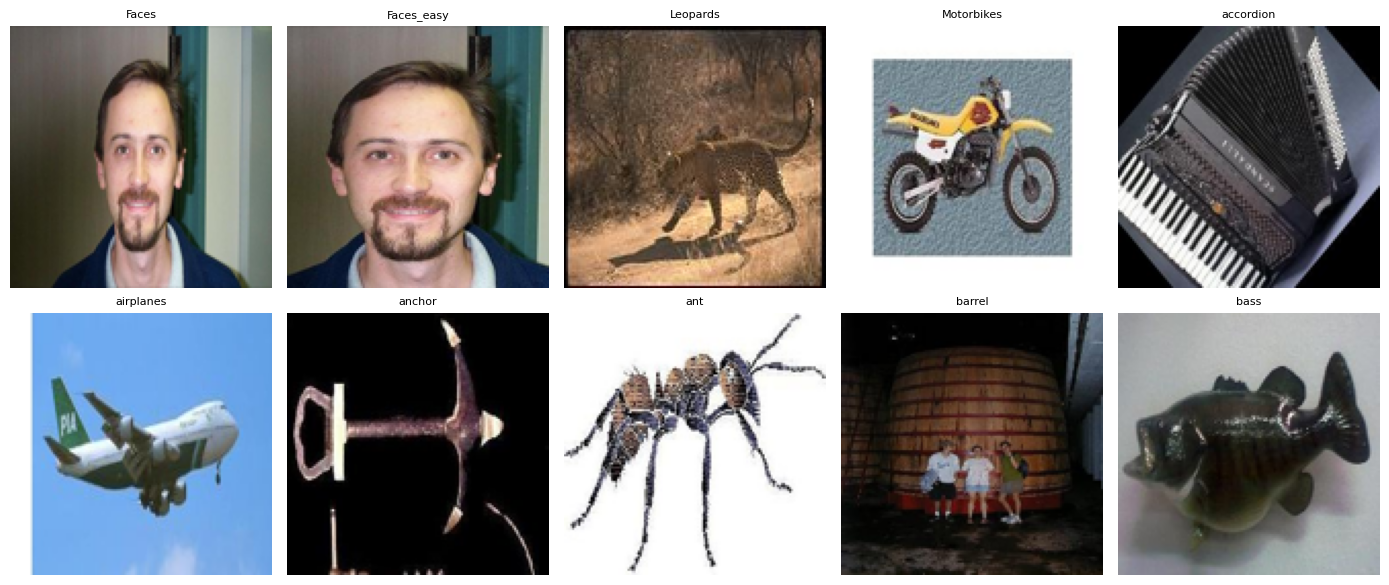

In [2]:
# ── 1. Point to your dataset root ──────────────────────────────────────────
DATA_DIR = Path("caltech-101") 

# ── 2. Discover all classes (sub-folders) ──────────────────────────────────
# filter to exclude hidden/system folders
classes = sorted([
    d.name for d in DATA_DIR.iterdir()
    if d.is_dir() and not d.name.startswith('.')  # excludes .ipynb_checkpoints
])

class_to_idx = {cls: i for i, cls in enumerate(classes)}

print(f"Found {len(classes)} classes")
print("First 10:", classes[:10])


# ── 3. Build a flat list of (image_path, label_index, class_name) ──────────
dataset = []
for cls in classes:
    for img_path in (DATA_DIR / cls).glob("*.jpg"):
        dataset.append((img_path, class_to_idx[cls], cls))

print(f"\nTotal images: {len(dataset)}")
print("Sample entry:", dataset[0])

# ── 4. Quick sanity check – open one image per class ──────────────────────
def load_image(path, size=(128, 128)):
    img = Image.open(path).convert("RGB").resize(size)
    return np.array(img)

# Show a few sample images
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
sample_classes = classes[:10]
for ax, cls in zip(axes.flat, sample_classes):
    sample_path = next((DATA_DIR / cls).glob("*.jpg"))
    ax.imshow(load_image(sample_path))
    ax.set_title(cls, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

df = pd.DataFrame(dataset, columns=["image_path", "label_index", "class_name"])
df.head(10)

,image_path,label_index,class_name
0,caltech-101/Faces/image_0146.jpg,0,Faces
1,caltech-101/Faces/image_0152.jpg,0,Faces
2,caltech-101/Faces/image_0185.jpg,0,Faces
3,caltech-101/Faces/image_0191.jpg,0,Faces
4,caltech-101/Faces/image_0378.jpg,0,Faces
5,caltech-101/Faces/image_0344.jpg,0,Faces
6,caltech-101/Faces/image_0422.jpg,0,Faces
7,caltech-101/Faces/image_0350.jpg,0,Faces
8,caltech-101/Faces/image_0387.jpg,0,Faces
9,caltech-101/Faces/image_0393.jpg,0,Faces


In [4]:
# ── 1. Build DataFrame ─────────────────────────────────────────────────────
DATA_DIR = Path("caltech-101")

records = []
for cls_folder in sorted(DATA_DIR.iterdir()):
    if cls_folder.is_dir():
        for img_path in cls_folder.glob("*.jpg"):
            records.append({"image_path": str(img_path), "class_name": cls_folder.name})

df = pd.DataFrame(records)

# Encode string labels → integers
le = LabelEncoder()
df["label"] = le.fit_transform(df["class_name"])

print(f"Total images : {len(df)}")
print(f"Total classes: {df['label'].nunique()}")
df.head()

Total images : 8677
Total classes: 101


,image_path,class_name,label
0,caltech-101/Faces/image_0146.jpg,Faces,0
1,caltech-101/Faces/image_0152.jpg,Faces,0
2,caltech-101/Faces/image_0185.jpg,Faces,0
3,caltech-101/Faces/image_0191.jpg,Faces,0
4,caltech-101/Faces/image_0378.jpg,Faces,0


In [5]:
# ── 2. Stratified split 70 / 15 / 15 ──────────────────────────────────────
# First split off 70% train
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)

# Split the remaining 30% equally into val and test (15% each)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df):>5} images ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val   : {len(val_df):>5} images ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test  : {len(test_df):>5} images ({len(test_df)/len(df)*100:.1f}%)")

Train :  6073 images (70.0%)
Val   :  1302 images (15.0%)
Test  :  1302 images (15.0%)


In [6]:
# ── 3a. For Classical ML → flat numpy arrays with HOG features ─────────────
IMG_SIZE = (128, 128)   # resize all images to this before HOG

def extract_hog(img_path):
    img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
    img_gray = rgb2gray(np.array(img))
    features = hog(img_gray, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), feature_vector=True)
    return features

def build_ml_arrays(dataframe):
    X, y = [], []
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        X.append(extract_hog(row["image_path"]))
        y.append(row["label"])
    return np.array(X, dtype=np.float32), np.array(y)

print("Extracting HOG features...")
X_train_ml, y_train_ml = build_ml_arrays(train_df)
X_val_ml,   y_val_ml   = build_ml_arrays(val_df)
X_test_ml,  y_test_ml  = build_ml_arrays(test_df)

print(f"X_train shape : {X_train_ml.shape}")   # (n_samples, n_hog_features)
print(f"X_val shape   : {X_val_ml.shape}")
print(f"X_test shape  : {X_test_ml.shape}")

Extracting HOG features...


100%|██████████████████████████████████████| 1302/1302 [00:04<00:00, 264.54it/s]


X_train shape : (6073, 8100)
X_val shape   : (1302, 8100)
X_test shape  : (1302, 8100)


In [7]:
# ── 3b. For Deep Learning → PyTorch DataLoaders ────────────────────────────
DL_IMG_SIZE = 224    # standard size for pretrained models
BATCH_SIZE  = 32

dl_transform = {
    "train": transforms.Compose([
        transforms.Resize((DL_IMG_SIZE, DL_IMG_SIZE)),
        transforms.RandomHorizontalFlip(),          # simple augmentation
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], # ImageNet mean/std
                             [0.229, 0.224, 0.225])
    ]),
    "val_test": transforms.Compose([
        transforms.Resize((DL_IMG_SIZE, DL_IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}

class Caltech101Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, row["label"]

train_loader = DataLoader(
    Caltech101Dataset(train_df, dl_transform["train"]),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0
)
val_loader = DataLoader(
    Caltech101Dataset(val_df,   dl_transform["val_test"]),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    Caltech101Dataset(test_df,  dl_transform["val_test"]),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

# Quick check
images, labels = next(iter(train_loader))
print(f"Batch shape : {images.shape}")   # (32, 3, 224, 224)
print(f"Labels shape: {labels.shape}")   # (32,)

Batch shape : torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


## Model 1: Classical ML - SVM + HOG features

In [8]:
# Make sure create the figures/ folder before running
os.makedirs("figures", exist_ok=True)

In [9]:
# ── SVM + HOG: Full Pipeline ───────────────────────────────────────────────
# Requirements: X_train_ml, y_train_ml, X_val_ml, y_val_ml, 
#               X_test_ml, y_test_ml, le  (from preprocessing cells)

# ── 1. Scale features (critical for SVM) ──────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_ml)   # fit only on train!
X_val_sc   = scaler.transform(X_val_ml)
X_test_sc  = scaler.transform(X_test_ml)

# ── 2. Train SVM ───────────────────────────────────────────────────────────
print("Training SVM... (this may take a few minutes)")
svm = SVC(kernel="rbf", C=10, gamma="scale",
          probability=True,   # needed for top-k accuracy
          random_state=42)
svm.fit(X_train_sc, y_train_ml)
print("Done!")

Training SVM... (this may take a few minutes)
Done!


In [10]:
# Save immediately after training, just call this cell next time and do not need to rerun the previous cell
import joblib
joblib.dump(svm,    "svm_model.pkl")
joblib.dump(scaler, "svm_scaler.pkl")
print("Model saved ✓")

Model saved ✓


In [11]:
# ── 3. Predictions ─────────────────────────────────────────────────────────
y_val_pred  = svm.predict(X_val_sc)
y_test_pred = svm.predict(X_test_sc)
y_test_prob = svm.predict_proba(X_test_sc)      # for top-k

In [12]:
# ── 4. Core Metrics ────────────────────────────────────────────────────────
test_acc = accuracy_score(y_test_ml, y_test_pred)
print(f"{'='*50}")
print(f"  SVM + HOG  —  Test Results")
print(f"{'='*50}")
print(f"  Overall Accuracy : {test_acc*100:.2f}%")

# Top-5 Accuracy (optional)
top5 = top_k_accuracy_score(y_test_ml, y_test_prob, k=5)
print(f"  Top-5 Accuracy   : {top5*100:.2f}%")

# Macro & Weighted Precision / Recall / F1
print(f"\n{'─'*50}")
print(classification_report(
    y_test_ml, y_test_pred,
    target_names=le.classes_,
    digits=3,
    zero_division=0
))

  SVM + HOG  —  Test Results
  Overall Accuracy : 62.67%
  Top-5 Accuracy   : 80.72%

──────────────────────────────────────────────────
                 precision    recall  f1-score   support

          Faces      0.598     0.970     0.740        66
     Faces_easy      0.971     1.000     0.985        66
       Leopards      0.509     0.967     0.667        30
     Motorbikes      0.968     1.000     0.984       120
      accordion      1.000     0.875     0.933         8
      airplanes      0.784     1.000     0.879       120
         anchor      0.000     0.000     0.000         6
            ant      0.000     0.000     0.000         6
         barrel      0.000     0.000     0.000         7
           bass      1.000     0.125     0.222         8
         beaver      1.000     0.143     0.250         7
      binocular      0.000     0.000     0.000         5
         bonsai      0.324     0.579     0.415        19
          brain      0.619     0.867     0.722        15
   bron

In [13]:
# ── 5. Per-class Accuracy ──────────────────────────────────────────────────
cm = confusion_matrix(y_test_ml, y_test_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

per_class_df = pd.DataFrame({
    "class"          : le.classes_,
    "per_class_acc"  : per_class_acc
}).sort_values("per_class_acc", ascending=False)

print("Top 10 best recognised classes:")
print(per_class_df.head(10).to_string(index=False))
print("\nTop 10 worst recognised classes:")
print(per_class_df.tail(10).to_string(index=False))

Top 10 best recognised classes:
      class  per_class_acc
 Motorbikes       1.000000
  airplanes       1.000000
  trilobite       1.000000
dollar_bill       1.000000
   car_side       1.000000
 Faces_easy       1.000000
      Faces       0.969697
   Leopards       0.966667
      watch       0.888889
  cellphone       0.888889

Top 10 worst recognised classes:
        class  per_class_acc
flamingo_head            0.0
          ant            0.0
     garfield            0.0
     platypus            0.0
   strawberry            0.0
       barrel            0.0
       cannon            0.0
       mayfly            0.0
      lobster            0.0
       snoopy            0.0


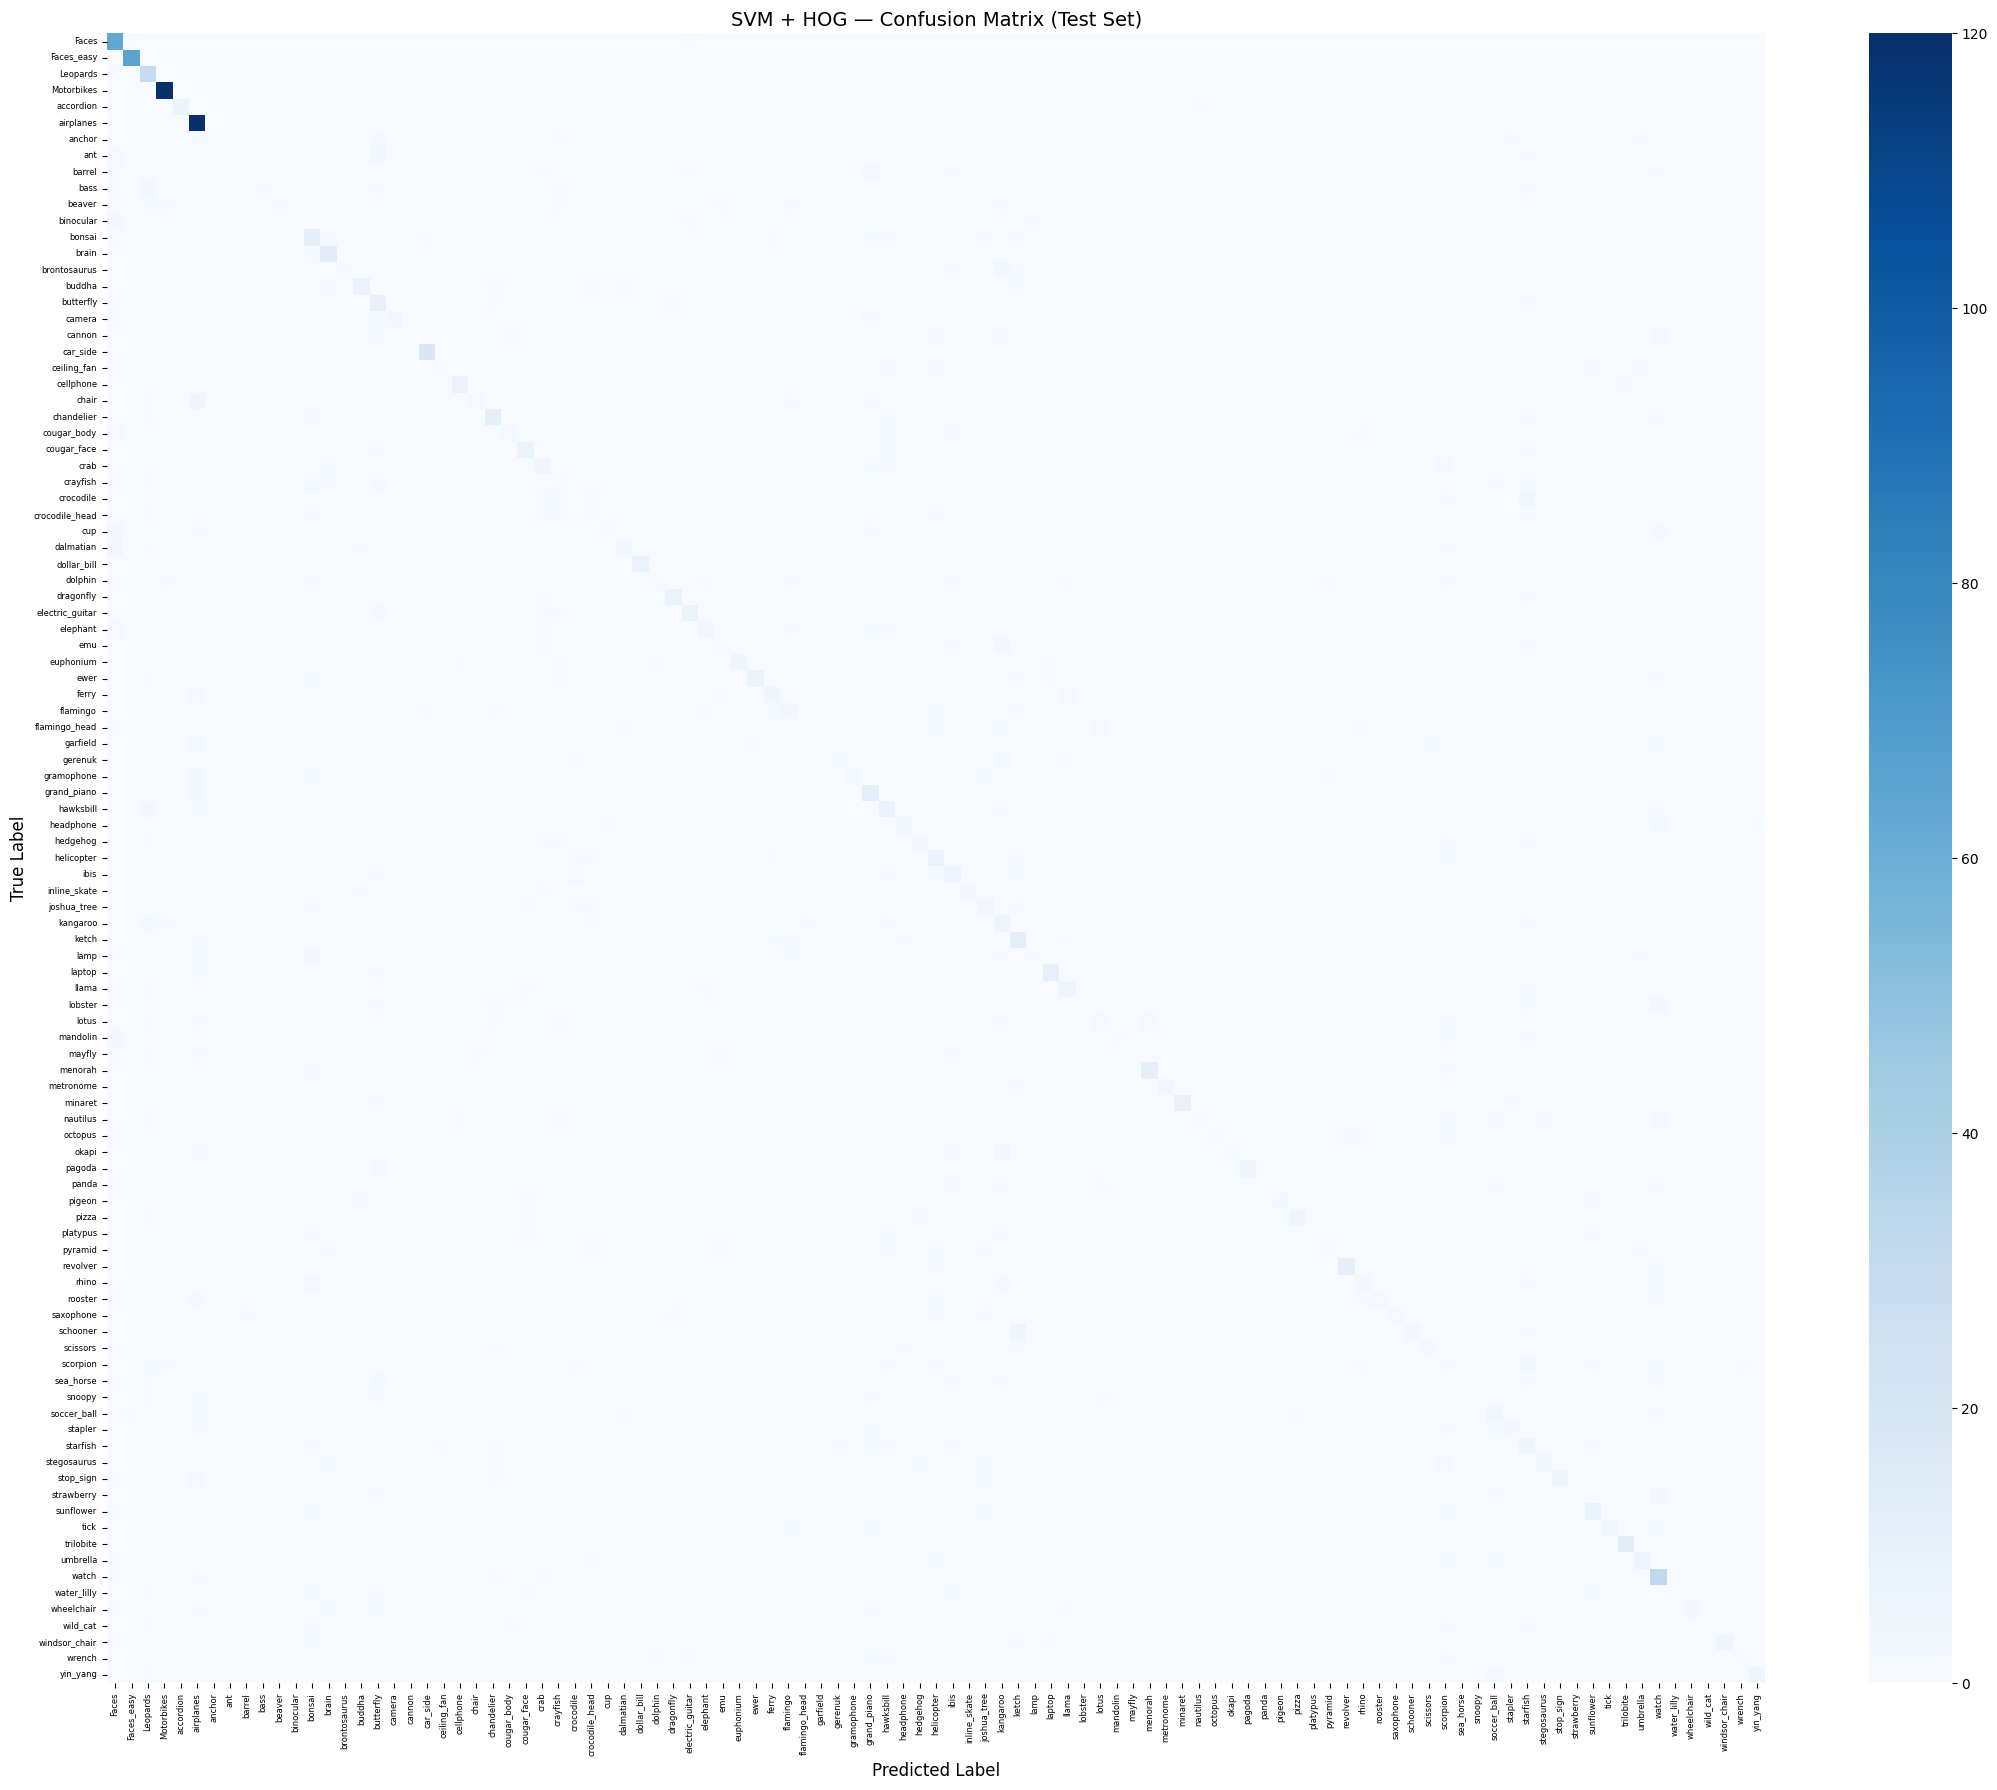

In [14]:
# ── 6. Confusion Matrix Plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            ax=ax)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("SVM + HOG — Confusion Matrix (Test Set)", fontsize=14)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0,  fontsize=6)
plt.tight_layout()
plt.savefig("figures/svm_confusion_matrix.png", dpi=150)
plt.show()

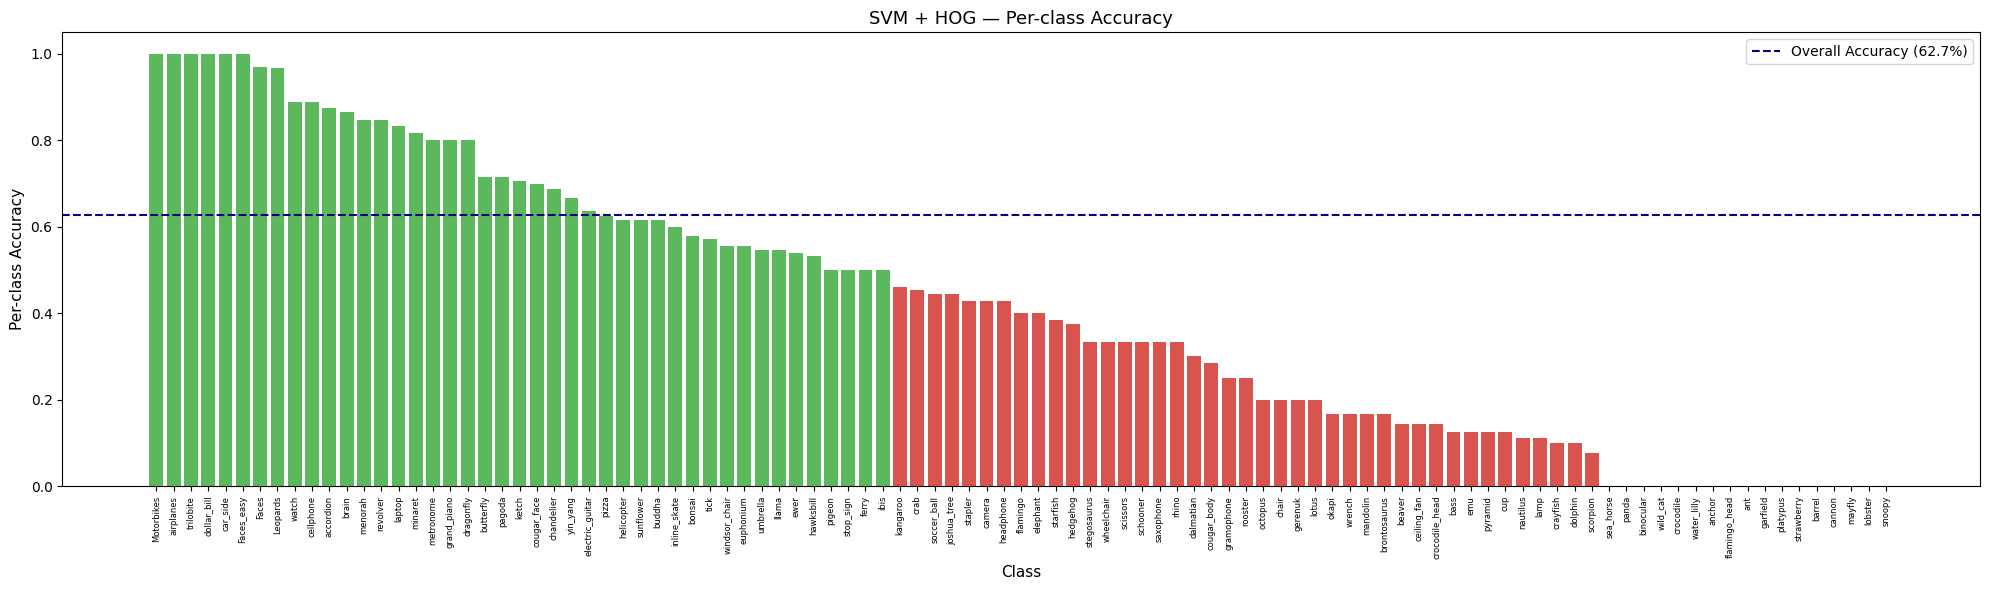

In [15]:
# ── 7. Per-class Accuracy Bar Chart ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 6))
colors = ["#d9534f" if v < 0.5 else "#5cb85c" for v in per_class_df["per_class_acc"]]
ax.bar(per_class_df["class"], per_class_df["per_class_acc"], color=colors)
ax.axhline(test_acc, color="navy", linestyle="--", linewidth=1.5,
           label=f"Overall Accuracy ({test_acc*100:.1f}%)")
ax.set_xlabel("Class", fontsize=11)
ax.set_ylabel("Per-class Accuracy", fontsize=11)
ax.set_title("SVM + HOG — Per-class Accuracy", fontsize=13)
ax.legend()
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig("figures/svm_per_class_accuracy.png", dpi=150)
plt.show()

Running ablation: image size (64, 64)...
  Accuracy: 67.36%
Running ablation: image size (128, 128)...
  Accuracy: 62.67%


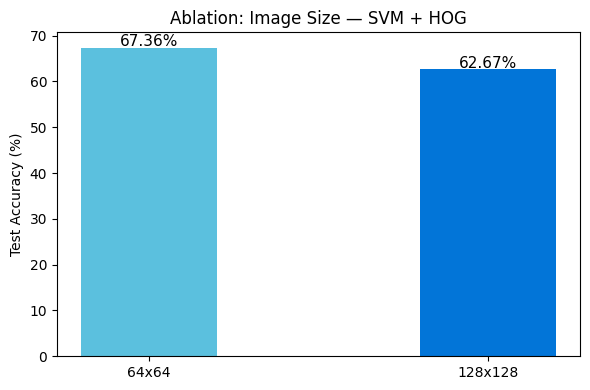

In [16]:
# ── 8. Ablation Study A: Image size 64x64 vs 128x128 ──────────────────────
from skimage.feature import hog
from skimage.color import rgb2gray

def extract_hog_custom(img_path, size):
    img = Image.open(img_path).convert("RGB").resize(size)
    img_gray = rgb2gray(np.array(img))
    return hog(img_gray, orientations=9, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), feature_vector=True)

def build_features(dataframe, size):
    X, y = [], []
    for _, row in dataframe.iterrows():
        X.append(extract_hog_custom(row["image_path"], size))
        y.append(row["label"])
    return np.array(X, dtype=np.float32), np.array(y)

ablation_results = {}

for img_size in [(64, 64), (128, 128)]:
    print(f"Running ablation: image size {img_size}...")
    X_tr, y_tr = build_features(train_df, img_size)
    X_te, y_te = build_features(test_df,  img_size)

    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)

    clf = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
    clf.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, clf.predict(X_te))
    ablation_results[f"{img_size[0]}x{img_size[1]}"] = acc
    print(f"  Accuracy: {acc*100:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(ablation_results.keys(), [v*100 for v in ablation_results.values()],
       color=["#5bc0de", "#0275d8"], width=0.4)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Ablation: Image Size — SVM + HOG")
for i, (k, v) in enumerate(ablation_results.items()):
    ax.text(i, v*100 + 0.3, f"{v*100:.2f}%", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("figures/svm_ablation_imgsize.png", dpi=150)
plt.show()

Extracting augmented features...


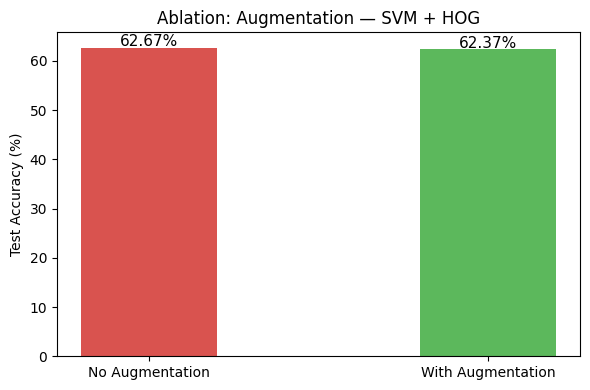

In [17]:
# ── 9. Ablation Study B: With vs Without Data Augmentation ─────────────────
# For classical ML, "augmentation" = horizontal flips added to training set

def augment_and_extract(dataframe, size=(128, 128)):
    X, y = [], []
    for _, row in dataframe.iterrows():
        img = Image.open(row["image_path"]).convert("RGB").resize(size)

        # Original
        gray = rgb2gray(np.array(img))
        X.append(hog(gray, orientations=9, pixels_per_cell=(8,8),
                     cells_per_block=(2,2), feature_vector=True))
        y.append(row["label"])

        # Flipped
        gray_flip = rgb2gray(np.array(img.transpose(Image.FLIP_LEFT_RIGHT)))
        X.append(hog(gray_flip, orientations=9, pixels_per_cell=(8,8),
                     cells_per_block=(2,2), feature_vector=True))
        y.append(row["label"])

    return np.array(X, dtype=np.float32), np.array(y)

aug_results = {}

# Without augmentation (reuse X_train_sc from step 1)
clf_no_aug = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
clf_no_aug.fit(X_train_sc, y_train_ml)
aug_results["No Augmentation"] = accuracy_score(y_test_ml,
                                    clf_no_aug.predict(X_test_sc))

# With augmentation
print("Extracting augmented features...")
X_aug, y_aug = augment_and_extract(train_df)
sc_aug = StandardScaler()
X_aug_sc  = sc_aug.fit_transform(X_aug)
X_test_aug = sc_aug.transform(X_test_ml)

clf_aug = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
clf_aug.fit(X_aug_sc, y_aug)
aug_results["With Augmentation"] = accuracy_score(y_test_ml,
                                      clf_aug.predict(X_test_aug))

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(aug_results.keys(), [v*100 for v in aug_results.values()],
       color=["#d9534f", "#5cb85c"], width=0.4)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Ablation: Augmentation — SVM + HOG")
for i, (k, v) in enumerate(aug_results.items()):
    ax.text(i, v*100 + 0.3, f"{v*100:.2f}%", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("figures/svm_ablation_augmentation.png", dpi=150)
plt.show()

## Model 2: ResNet-50 (Transfer Learning)

In [21]:
# ── ResNet-50 Transfer Learning: Setup ────────────────────────────────────
DEVICE     = torch.device("mps" if torch.backends.mps.is_available()   # Apple Silicon
                     else "cuda" if torch.cuda.is_available()           # NVIDIA GPU
                     else "cpu")                                        # fallback
NUM_CLASSES = len(le.classes_)   # 101
print(f"Using device : {DEVICE}")
print(f"Num classes  : {NUM_CLASSES}")

Using device : mps
Num classes  : 101


In [22]:
# ── Build ResNet-50 Model ──────────────────────────────────────────────────
def build_resnet(num_classes, freeze_backbone=True):
    model = models.resnet50(weights="IMAGENET1K_V1")   # pretrained weights

    if freeze_backbone:
        # Freeze all layers except the final classifier
        for param in model.parameters():
            param.requires_grad = False

    # Replace final FC layer to match our 101 classes
    in_features = model.fc.in_features       # 2048 for ResNet-50
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

resnet = build_resnet(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

# Count trainable parameters
total     = sum(p.numel() for p in resnet.parameters())
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")   # only the new FC layer

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/cindysun/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████████████████████████████████| 97.8M/97.8M [00:11<00:00, 8.65MB/s]


Total params    : 23,714,981
Trainable params: 206,949


In [23]:
# ── Training Function ──────────────────────────────────────────────────────
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, num_epochs=20, device=DEVICE):

    history = {"train_loss": [], "train_acc": [],
               "val_loss":   [], "val_acc":   []}

    best_weights = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        t0 = time.time()

        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()
            loader = train_loader if phase == "train" else val_loader

            running_loss, running_correct = 0.0, 0

            for images, labels in loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(images)
                    loss    = criterion(outputs, labels)
                    preds   = outputs.argmax(dim=1)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss    += loss.item() * images.size(0)
                running_correct += (preds == labels).sum().item()

            epoch_loss = running_loss    / len(loader.dataset)
            epoch_acc  = running_correct / len(loader.dataset)
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            if phase == "val" and epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                best_weights = copy.deepcopy(model.state_dict())

        if scheduler:
            scheduler.step()

        elapsed = time.time() - t0
        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"Train Loss: {history['train_loss'][-1]:.4f}  Acc: {history['train_acc'][-1]*100:.2f}%  | "
              f"Val Loss: {history['val_loss'][-1]:.4f}  Acc: {history['val_acc'][-1]*100:.2f}%  | "
              f"Time: {elapsed:.1f}s")

    print(f"\nBest Val Accuracy: {best_val_acc*100:.2f}%")
    model.load_state_dict(best_weights)   # restore best weights
    return model, history

In [24]:
# ── Phase 1: Train only the FC head (frozen backbone) ─────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()),
    lr=1e-3
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print("Phase 1: Training FC head only (backbone frozen)...")
resnet, history_phase1 = train_model(
    resnet, train_loader, val_loader,
    criterion, optimizer, scheduler,
    num_epochs=10
)

Phase 1: Training FC head only (backbone frozen)...
Epoch [01/10] Train Loss: 2.0410  Acc: 59.49%  | Val Loss: 0.6731  Acc: 85.56%  | Time: 113.8s
Epoch [02/10] Train Loss: 0.6497  Acc: 84.98%  | Val Loss: 0.4046  Acc: 91.40%  | Time: 240.7s
Epoch [03/10] Train Loss: 0.4512  Acc: 88.33%  | Val Loss: 0.3422  Acc: 91.47%  | Time: 104.3s
Epoch [04/10] Train Loss: 0.3692  Acc: 90.50%  | Val Loss: 0.2882  Acc: 92.24%  | Time: 105.2s
Epoch [05/10] Train Loss: 0.3195  Acc: 91.62%  | Val Loss: 0.2818  Acc: 92.24%  | Time: 250.9s
Epoch [06/10] Train Loss: 0.2792  Acc: 92.11%  | Val Loss: 0.2795  Acc: 93.01%  | Time: 130.0s
Epoch [07/10] Train Loss: 0.2492  Acc: 93.07%  | Val Loss: 0.2755  Acc: 91.78%  | Time: 104.0s
Epoch [08/10] Train Loss: 0.1853  Acc: 95.44%  | Val Loss: 0.2277  Acc: 93.63%  | Time: 951.8s
Epoch [09/10] Train Loss: 0.1709  Acc: 95.72%  | Val Loss: 0.2247  Acc: 93.78%  | Time: 104.6s
Epoch [10/10] Train Loss: 0.1830  Acc: 95.26%  | Val Loss: 0.2283  Acc: 93.63%  | Time: 191.0

In [25]:
# ── Phase 2: Unfreeze and fine-tune the whole model ────────────────────────
# Unfreeze all layers
for param in resnet.parameters():
    param.requires_grad = True

# Lower LR for fine-tuning to avoid destroying pretrained weights
optimizer_ft = optim.Adam(resnet.parameters(), lr=1e-4)
scheduler_ft = optim.lr_scheduler.StepLR(optimizer_ft, step_size=5, gamma=0.1)

print("Phase 2: Fine-tuning entire network...")
resnet, history_phase2 = train_model(
    resnet, train_loader, val_loader,
    criterion, optimizer_ft, scheduler_ft,
    num_epochs=10
)

# Merge histories
history_resnet = {
    k: history_phase1[k] + history_phase2[k]
    for k in history_phase1
}

Phase 2: Fine-tuning entire network...
Epoch [01/10] Train Loss: 0.2254  Acc: 93.22%  | Val Loss: 0.2066  Acc: 94.32%  | Time: 2681.6s
Epoch [02/10] Train Loss: 0.1009  Acc: 96.90%  | Val Loss: 0.2002  Acc: 94.16%  | Time: 728.7s
Epoch [03/10] Train Loss: 0.0856  Acc: 97.68%  | Val Loss: 0.2152  Acc: 94.01%  | Time: 919.2s
Epoch [04/10] Train Loss: 0.0425  Acc: 98.93%  | Val Loss: 0.1895  Acc: 95.31%  | Time: 703.8s
Epoch [05/10] Train Loss: 0.0446  Acc: 98.72%  | Val Loss: 0.2061  Acc: 94.24%  | Time: 655.6s
Epoch [06/10] Train Loss: 0.0228  Acc: 99.46%  | Val Loss: 0.1625  Acc: 95.47%  | Time: 673.9s
Epoch [07/10] Train Loss: 0.0160  Acc: 99.65%  | Val Loss: 0.1533  Acc: 95.55%  | Time: 585.8s
Epoch [08/10] Train Loss: 0.0105  Acc: 99.82%  | Val Loss: 0.1497  Acc: 95.85%  | Time: 1718.8s
Epoch [09/10] Train Loss: 0.0076  Acc: 99.88%  | Val Loss: 0.1476  Acc: 96.01%  | Time: 666.8s
Epoch [10/10] Train Loss: 0.0064  Acc: 99.90%  | Val Loss: 0.1423  Acc: 96.08%  | Time: 693.0s

Best Val

In [26]:
# ── Save model immediately ─────────────────────────────────────────────────
torch.save(resnet.state_dict(), "resnet50_caltech101.pth")
print("Model saved ✓")

# To reload later:
# resnet = build_resnet(NUM_CLASSES).to(DEVICE)
# resnet.load_state_dict(torch.load("resnet50_caltech101.pth"))

Model saved ✓


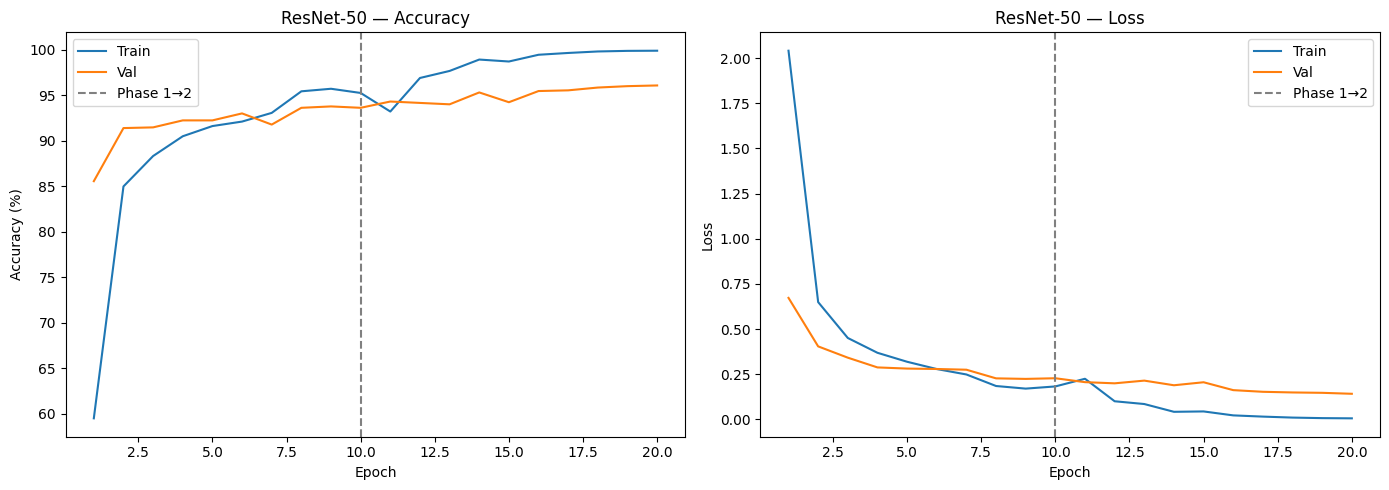

In [27]:
# ── Training Curves ────────────────────────────────────────────────────────
epochs = range(1, len(history_resnet["train_acc"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, [a*100 for a in history_resnet["train_acc"]], label="Train")
ax1.plot(epochs, [a*100 for a in history_resnet["val_acc"]],   label="Val")
ax1.axvline(x=10, color="gray", linestyle="--", label="Phase 1→2")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy (%)")
ax1.set_title("ResNet-50 — Accuracy"); ax1.legend()

ax2.plot(epochs, history_resnet["train_loss"], label="Train")
ax2.plot(epochs, history_resnet["val_loss"],   label="Val")
ax2.axvline(x=10, color="gray", linestyle="--", label="Phase 1→2")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.set_title("ResNet-50 — Loss"); ax2.legend()

plt.tight_layout()
plt.savefig("figures/resnet_training_curves.png", dpi=150)
plt.show()

In [28]:
# ── Evaluation on Test Set ─────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import top_k_accuracy_score
import numpy as np

resnet.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = resnet(images)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())
        all_probs.append(probs.cpu().numpy())

y_test_pred_resnet = np.concatenate(all_preds)
y_test_true_resnet = np.concatenate(all_labels)
y_test_prob_resnet = np.concatenate(all_probs)

# Metrics
test_acc = accuracy_score(y_test_true_resnet, y_test_pred_resnet)
top5_acc = top_k_accuracy_score(y_test_true_resnet, y_test_prob_resnet, k=5)

print(f"{'='*50}")
print(f"  ResNet-50 — Test Results")
print(f"{'='*50}")
print(f"  Overall Accuracy : {test_acc*100:.2f}%")
print(f"  Top-5 Accuracy   : {top5_acc*100:.2f}%")
print(f"\n{'─'*50}")
print(classification_report(
    y_test_true_resnet, y_test_pred_resnet,
    target_names=le.classes_, digits=3, zero_division=0
))

  ResNet-50 — Test Results
  Overall Accuracy : 96.62%
  Top-5 Accuracy   : 99.85%

──────────────────────────────────────────────────
                 precision    recall  f1-score   support

          Faces      1.000     0.985     0.992        66
     Faces_easy      0.985     1.000     0.992        66
       Leopards      1.000     1.000     1.000        30
     Motorbikes      1.000     1.000     1.000       120
      accordion      0.889     1.000     0.941         8
      airplanes      1.000     1.000     1.000       120
         anchor      0.714     0.833     0.769         6
            ant      1.000     0.833     0.909         6
         barrel      1.000     0.857     0.923         7
           bass      1.000     0.875     0.933         8
         beaver      1.000     0.857     0.923         7
      binocular      1.000     1.000     1.000         5
         bonsai      1.000     1.000     1.000        19
          brain      1.000     0.867     0.929        15
   bronto

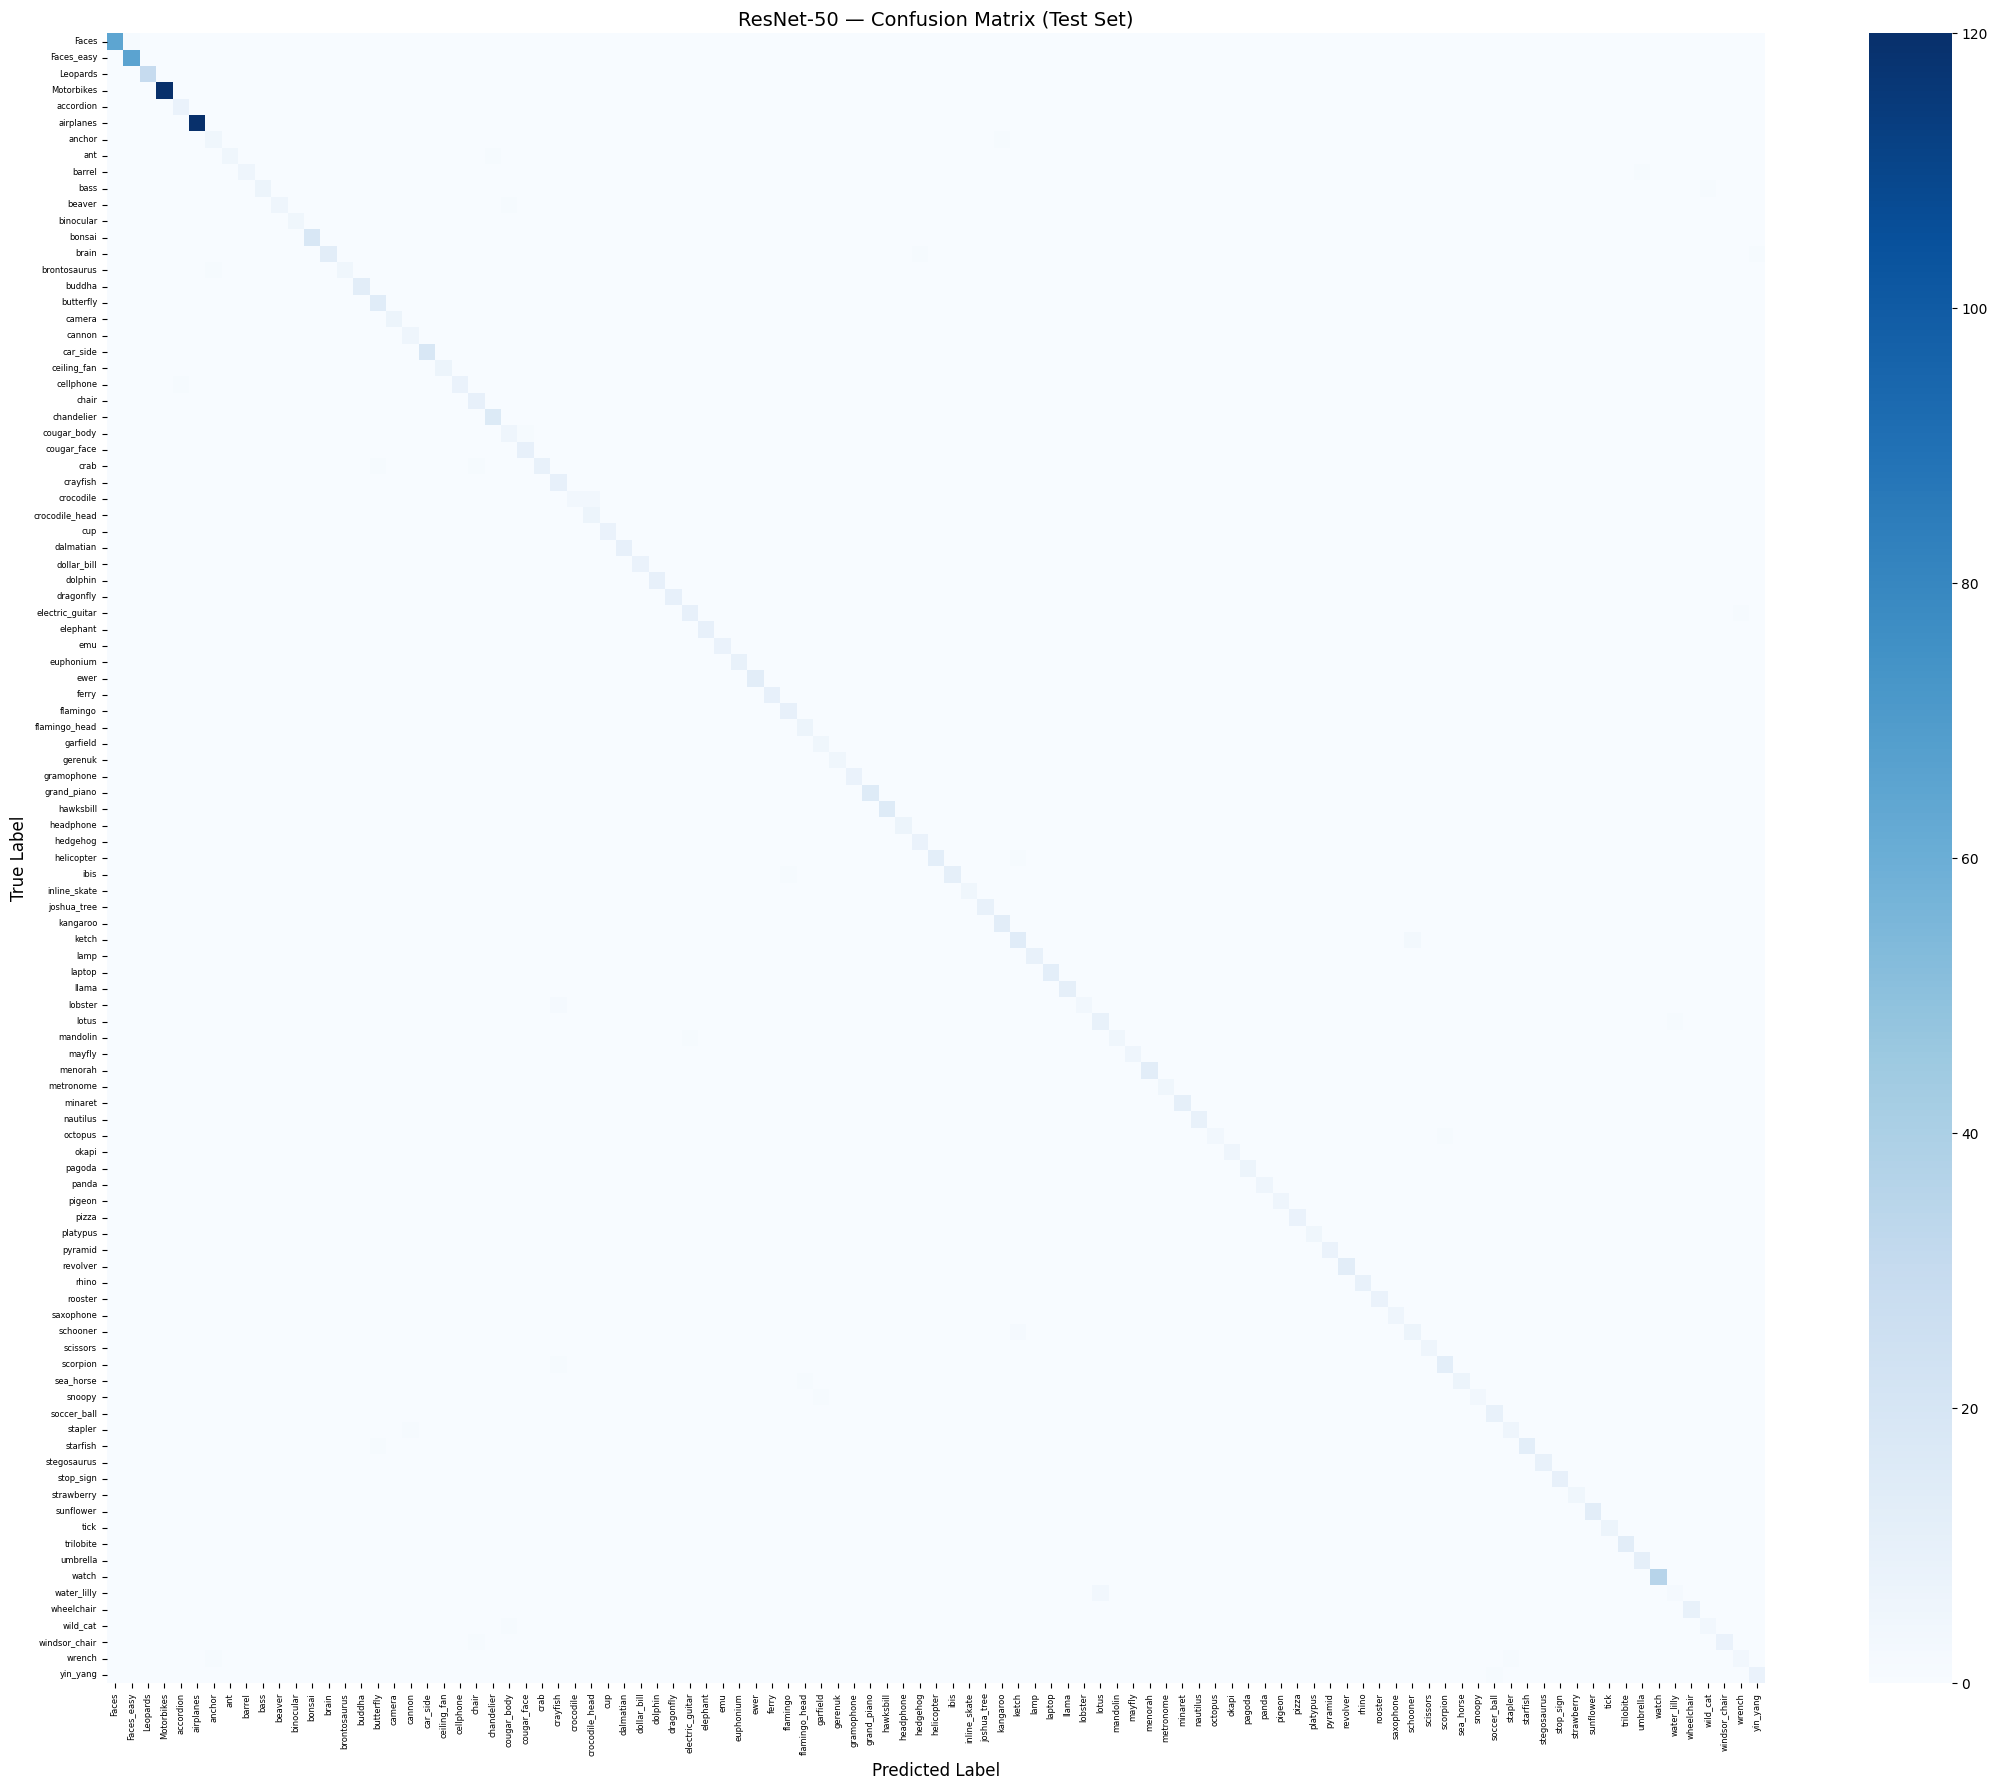

In [29]:
# ── Confusion Matrix ───────────────────────────────────────────────────────
cm_resnet = confusion_matrix(y_test_true_resnet, y_test_pred_resnet)

fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(cm_resnet, annot=False, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("ResNet-50 — Confusion Matrix (Test Set)", fontsize=14)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0,  fontsize=6)
plt.tight_layout()
plt.savefig("figures/resnet_confusion_matrix.png", dpi=150)
plt.show()

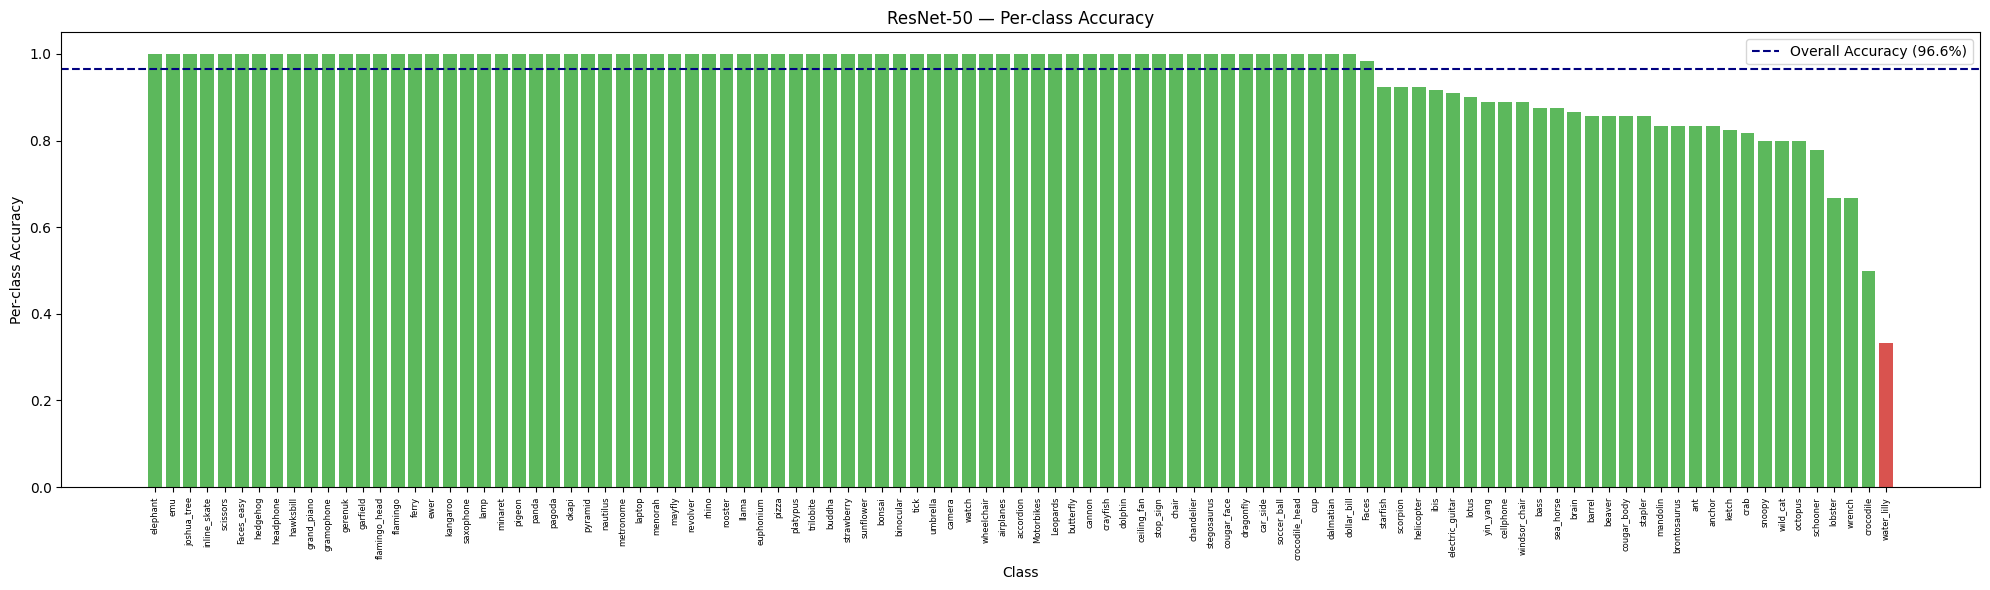

In [30]:
# ── Per-class Accuracy ─────────────────────────────────────────────────────
per_class_acc_resnet = cm_resnet.diagonal() / cm_resnet.sum(axis=1)

per_class_df_resnet = pd.DataFrame({
    "class"        : le.classes_,
    "per_class_acc": per_class_acc_resnet
}).sort_values("per_class_acc", ascending=False)

fig, ax = plt.subplots(figsize=(20, 6))
colors = ["#d9534f" if v < 0.5 else "#5cb85c" for v in per_class_df_resnet["per_class_acc"]]
ax.bar(per_class_df_resnet["class"], per_class_df_resnet["per_class_acc"], color=colors)
ax.axhline(test_acc, color="navy", linestyle="--", linewidth=1.5,
           label=f"Overall Accuracy ({test_acc*100:.1f}%)")
ax.set_xlabel("Class"); ax.set_ylabel("Per-class Accuracy")
ax.set_title("ResNet-50 — Per-class Accuracy")
ax.legend()
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig("figures/resnet_per_class_accuracy.png", dpi=150)
plt.show()

## Model 3: Vision Transformer (ViT)

In [31]:
# ── ViT: Setup ────────────────────────────────────────────────────────────
print(f"timm version : {timm.__version__}")
print(f"Using device : {DEVICE}")

timm version : 1.0.25
Using device : mps


In [32]:
# ── Build ViT Model ────────────────────────────────────────────────────────
def build_vit(num_classes, freeze_backbone=True):
    # ViT-Base/16 pretrained on ImageNet-21k then finetuned on ImageNet-1k
    model = timm.create_model(
        "vit_base_patch16_224",
        pretrained=True,
        num_classes=0          # remove the original head
    )

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Get the embedding dimension (768 for ViT-Base)
    embed_dim = model.num_features

    # Attach our own classification head
    model.head = nn.Sequential(
        nn.LayerNorm(embed_dim),
        nn.Dropout(0.5),
        nn.Linear(embed_dim, num_classes)
    )

    return model

vit = build_vit(NUM_CLASSES, freeze_backbone=True).to(DEVICE)

# Count parameters
total     = sum(p.numel() for p in vit.parameters())
trainable = sum(p.numel() for p in vit.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")   # only the new head

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Total params    : 85,877,861
Trainable params: 79,205


In [33]:
# ── Phase 1: Train head only (backbone frozen) ────────────────────────────
criterion_vit = nn.CrossEntropyLoss(label_smoothing=0.1)  # smoothing helps ViT
optimizer_vit = optim.Adam(
    filter(lambda p: p.requires_grad, vit.parameters()),
    lr=1e-3
)
scheduler_vit = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_vit, T_max=10   # cosine decay over 10 epochs
)

print("Phase 1: Training head only (backbone frozen)...")
vit, history_vit_phase1 = train_model(       # reuses the same train_model function from ResNet
    vit, train_loader, val_loader,
    criterion_vit, optimizer_vit, scheduler_vit,
    num_epochs=10
)

Phase 1: Training head only (backbone frozen)...
Epoch [01/10] Train Loss: 1.8023  Acc: 76.39%  | Val Loss: 1.0663  Acc: 93.39%  | Time: 357.4s
Epoch [02/10] Train Loss: 1.0744  Acc: 94.83%  | Val Loss: 1.0086  Acc: 95.31%  | Time: 301.3s
Epoch [03/10] Train Loss: 1.0374  Acc: 95.64%  | Val Loss: 0.9935  Acc: 95.70%  | Time: 781.3s
Epoch [04/10] Train Loss: 1.0156  Acc: 96.25%  | Val Loss: 0.9820  Acc: 96.01%  | Time: 326.8s
Epoch [05/10] Train Loss: 0.9997  Acc: 97.07%  | Val Loss: 0.9763  Acc: 96.47%  | Time: 774.1s
Epoch [06/10] Train Loss: 0.9962  Acc: 96.94%  | Val Loss: 0.9698  Acc: 96.08%  | Time: 405.5s
Epoch [07/10] Train Loss: 0.9853  Acc: 97.23%  | Val Loss: 0.9693  Acc: 96.47%  | Time: 289.8s
Epoch [08/10] Train Loss: 0.9827  Acc: 97.63%  | Val Loss: 0.9703  Acc: 96.31%  | Time: 1128.8s


KeyboardInterrupt: 

In [ ]:
# ── Phase 2: Unfreeze and fine-tune entire ViT ────────────────────────────
for param in vit.parameters():
    param.requires_grad = True

# ViT needs a very small LR when fine-tuning — larger LR destroys attention weights
optimizer_vit_ft = optim.AdamW(
    vit.parameters(),
    lr=2e-5,           # much smaller than ResNet fine-tune LR
    weight_decay=0.01  # AdamW weight decay helps ViT generalize
)
scheduler_vit_ft = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_vit_ft, T_max=10
)

print("Phase 2: Fine-tuning entire ViT...")
vit, history_vit_phase2 = train_model(
    vit, train_loader, val_loader,
    criterion_vit, optimizer_vit_ft, scheduler_vit_ft,
    num_epochs=10
)

# Merge histories
history_vit = {
    k: history_vit_phase1[k] + history_vit_phase2[k]
    for k in history_vit_phase1
}

In [ ]:
# ── Save model immediately ─────────────────────────────────────────────────
torch.save(vit.state_dict(), "vit_caltech101.pth")
print("ViT model saved ✓")

# To reload later:
# vit = build_vit(NUM_CLASSES).to(DEVICE)
# vit.load_state_dict(torch.load("vit_caltech101.pth"))

In [ ]:
# ── Training Curves ────────────────────────────────────────────────────────
epochs = range(1, len(history_vit["train_acc"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, [a*100 for a in history_vit["train_acc"]], label="Train")
ax1.plot(epochs, [a*100 for a in history_vit["val_acc"]],   label="Val")
ax1.axvline(x=10, color="gray", linestyle="--", label="Phase 1→2")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy (%)")
ax1.set_title("ViT-B/16 — Accuracy"); ax1.legend()

ax2.plot(epochs, history_vit["train_loss"], label="Train")
ax2.plot(epochs, history_vit["val_loss"],   label="Val")
ax2.axvline(x=10, color="gray", linestyle="--", label="Phase 1→2")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.set_title("ViT-B/16 — Loss"); ax2.legend()

plt.tight_layout()
plt.savefig("figures/vit_training_curves.png", dpi=150)
plt.show()

In [ ]:
# ── Evaluation on Test Set ─────────────────────────────────────────────────
vit.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = vit(images)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())
        all_probs.append(probs.cpu().numpy())

y_test_pred_vit = np.concatenate(all_preds)
y_test_true_vit = np.concatenate(all_labels)
y_test_prob_vit = np.concatenate(all_probs)

# Metrics
test_acc_vit = accuracy_score(y_test_true_vit, y_test_pred_vit)
top5_acc_vit = top_k_accuracy_score(y_test_true_vit, y_test_prob_vit, k=5)

print(f"{'='*50}")
print(f"  ViT-B/16 — Test Results")
print(f"{'='*50}")
print(f"  Overall Accuracy : {test_acc_vit*100:.2f}%")
print(f"  Top-5 Accuracy   : {top5_acc_vit*100:.2f}%")
print(f"\n{'─'*50}")
print(classification_report(
    y_test_true_vit, y_test_pred_vit,
    target_names=le.classes_, digits=3, zero_division=0
))

In [ ]:
# ── Confusion Matrix ───────────────────────────────────────────────────────
cm_vit = confusion_matrix(y_test_true_vit, y_test_pred_vit)

fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(cm_vit, annot=False, fmt="d", cmap="Purples",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("ViT-B/16 — Confusion Matrix (Test Set)", fontsize=14)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0,  fontsize=6)
plt.tight_layout()
plt.savefig("figures/vit_confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
# ── Per-class Accuracy ─────────────────────────────────────────────────────
per_class_acc_vit = cm_vit.diagonal() / cm_vit.sum(axis=1)

per_class_df_vit = pd.DataFrame({
    "class"        : le.classes_,
    "per_class_acc": per_class_acc_vit
}).sort_values("per_class_acc", ascending=False)

fig, ax = plt.subplots(figsize=(20, 6))
colors = ["#d9534f" if v < 0.5 else "#9b59b6" for v in per_class_df_vit["per_class_acc"]]
ax.bar(per_class_df_vit["class"], per_class_df_vit["per_class_acc"], color=colors)
ax.axhline(test_acc_vit, color="navy", linestyle="--", linewidth=1.5,
           label=f"Overall Accuracy ({test_acc_vit*100:.1f}%)")
ax.set_xlabel("Class"); ax.set_ylabel("Per-class Accuracy")
ax.set_title("ViT-B/16 — Per-class Accuracy")
ax.legend()
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig("figures/vit_per_class_accuracy.png", dpi=150)
plt.show()

In [ ]:
# ── Attention Map Visualization (XAI) ─────────────────────────────────────
# Shows what patches ViT "attends to" — great for your report's XAI section

def visualize_attention(model, image_tensor, class_name, device=DEVICE):
    model.eval()
    img = image_tensor.unsqueeze(0).to(device)

    attention_maps = []

    def hook_fn(module, input, output):
        # output shape: (batch, heads, seq_len, seq_len)
        attention_maps.append(output.detach().cpu())

    # Register hook on the last attention block
    hook = model.blocks[-1].attn.register_forward_hook(hook_fn)

    with torch.no_grad():
        _ = model(img)
    hook.remove()

    # Average over attention heads, take CLS token attention to patches
    attn = attention_maps[0][0]          # (heads, seq_len, seq_len)
    attn = attn.mean(0)                  # average heads → (seq_len, seq_len)
    cls_attn = attn[0, 1:]               # CLS token → all 196 patches

    # Reshape to 14x14 spatial grid
    attn_map = cls_attn.reshape(14, 14).numpy()
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())

    # Original image (denormalize)
    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])
    orig = image_tensor.cpu() * std[:, None, None] + mean[:, None, None]
    orig = orig.permute(1, 2, 0).clamp(0, 1).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(orig);                         axes[0].set_title("Original")
    axes[1].imshow(attn_map, cmap="hot");         axes[1].set_title("Attention Map")
    axes[2].imshow(orig);
    axes[2].imshow(attn_map, cmap="hot", alpha=0.5); axes[2].set_title("Overlay")
    for ax in axes: ax.axis("off")
    plt.suptitle(f"ViT Attention — Class: {class_name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"figures/vit_attention_{class_name}.png", dpi=150)
    plt.show()

# Visualize attention for a few test samples
for i in range(3):
    img_tensor, label = Caltech101Dataset(test_df, dl_transform["val_test"])[i]
    class_name = le.classes_[label]
    visualize_attention(vit, img_tensor, class_name)